## **Exploratory Data Analysis**

### **1. Download dataset**

In [1]:
COCO_ROOT="/content/coco"
!mkdir -p $COCO_ROOT

# Download train2017 images
!wget -nc http://images.cocodataset.org/zips/train2017.zip -P $COCO_ROOT
!unzip -q $COCO_ROOT/train2017.zip -d $COCO_ROOT

# Download annotations (vẫn dùng chung cho train + val)
!wget -nc http://images.cocodataset.org/annotations/annotations_trainval2017.zip -P $COCO_ROOT
!unzip -q $COCO_ROOT/annotations_trainval2017.zip -d $COCO_ROOT

--2026-04-06 12:24:07--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 16.15.252.158, 16.15.212.194, 16.15.236.102, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|16.15.252.158|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘/content/coco/train2017.zip’

train2017.zip       100%[===================>]  18.01G  55.1MB/s    in 6m 41s  

2026-04-06 12:30:48 (45.9 MB/s) - ‘/content/coco/train2017.zip’ saved [19336861798/19336861798]

--2026-04-06 12:34:16--  http://images.cocodataset.org/annotations/annotations_trainval2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.82.20, 16.15.191.82, 16.15.223.48, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.82.20|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 252907541 (241M) [application/zip]
Saving to: ‘/content/coco

In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from tqdm import tqdm

# =========================
# PATH CONFIG
# =========================
ANN_PATH = f"{COCO_ROOT}/annotations/instances_train2017.json"
IMG_DIR = f"{COCO_ROOT}/train2017"

# =========================
# LOAD JSON
# =========================
with open(ANN_PATH, 'r') as f:
    coco = json.load(f)

images = coco['images']
annotations = coco['annotations']
categories = coco['categories']

print(f"Num images: {len(images)}")
print(f"Num annotations: {len(annotations)}")
print(f"Num categories: {len(categories)}")

Num images: 118287
Num annotations: 860001
Num categories: 80


### **2. Số object mỗi ảnh**

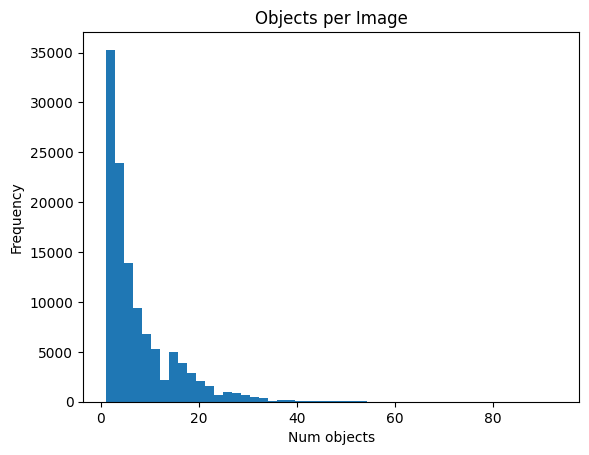

Mean objects/image: 7.33376255692187
Max objects/image: 93


In [3]:
img_id_to_count = Counter()

for ann in annotations:
    img_id_to_count[ann['image_id']] += 1

counts = list(img_id_to_count.values())

plt.figure()
plt.hist(counts, bins=50)
plt.title("Objects per Image")
plt.xlabel("Num objects")
plt.ylabel("Frequency")
plt.show()

print("Mean objects/image:", np.mean(counts))
print("Max objects/image:", np.max(counts))

### **3. Phân bố class**

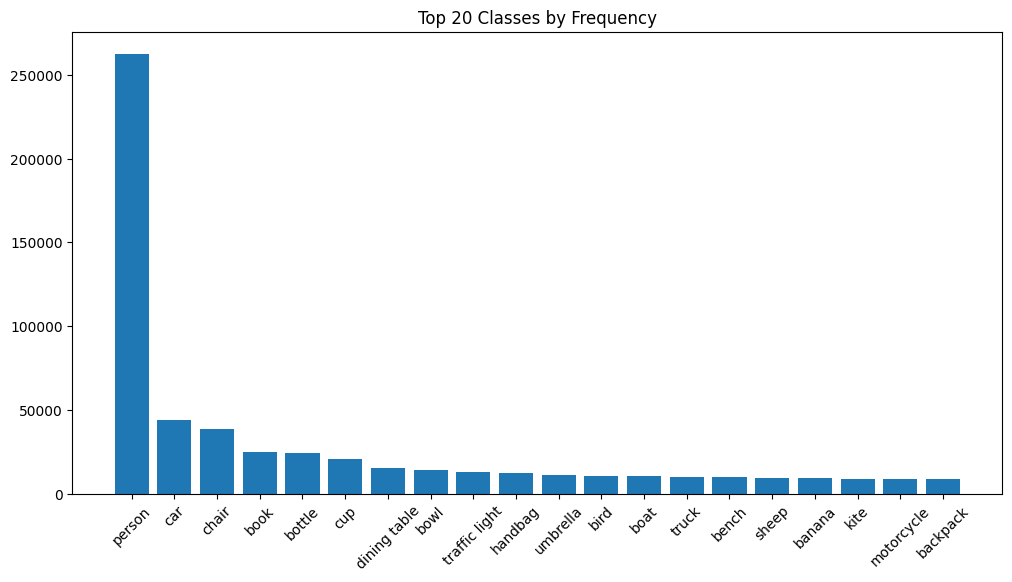

In [7]:
import json
from collections import Counter
import matplotlib.pyplot as plt

# load JSON COCO
with open("coco/annotations/instances_train2017.json", "r") as f:
    coco = json.load(f)

annotations = coco['annotations']

# Tạo map từ id -> name
cat_id_to_name = {cat['id']: cat['name'] for cat in coco['categories']}

# Đếm số lượng mỗi category_id
cat_counter = Counter()
for ann in annotations:
    cat_counter[ann['category_id']] += 1

# convert sang tên
cat_names = [cat_id_to_name[cid] for cid in cat_counter.keys()]
cat_values = list(cat_counter.values())

# sort
sorted_pairs = sorted(zip(cat_names, cat_values), key=lambda x: x[1], reverse=True)

names = [x[0] for x in sorted_pairs]
values = [x[1] for x in sorted_pairs]

plt.figure(figsize=(12,6))
plt.bar(names[:20], values[:20])  # top 20 class
plt.xticks(rotation=45)
plt.title("Top 20 Classes by Frequency")
plt.show()

### **4. Phân tích bounding box**

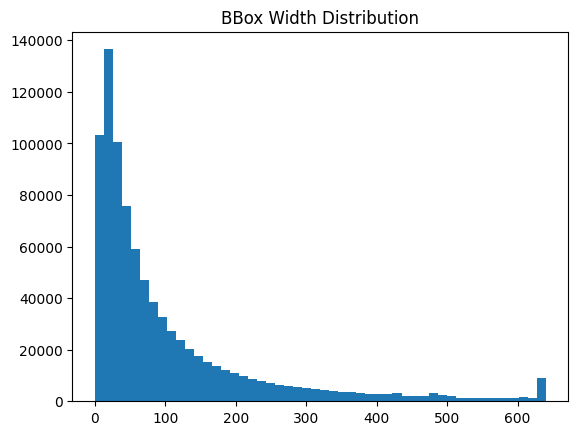

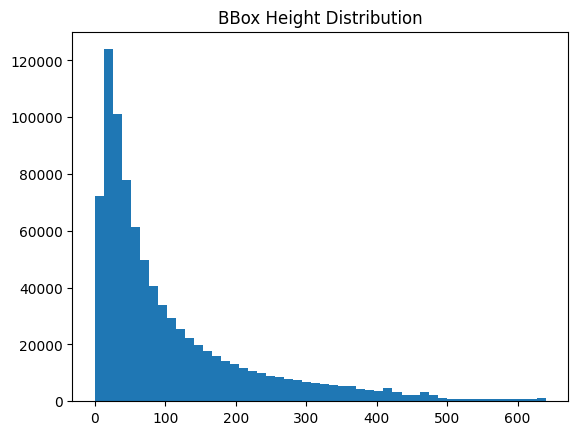

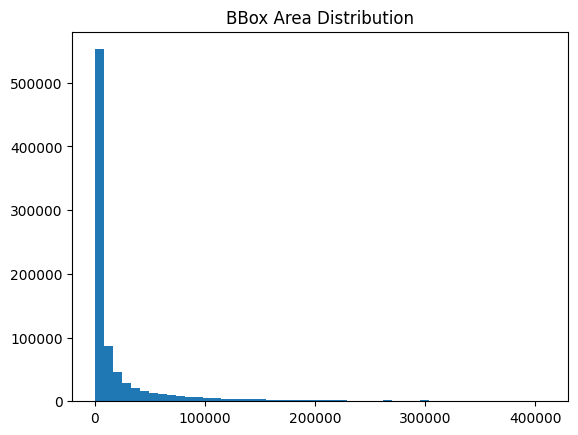

In [8]:
widths = []
heights = []
areas = []

for ann in annotations:
    x, y, w, h = ann['bbox']
    widths.append(w)
    heights.append(h)
    areas.append(w * h)

# Width
plt.figure()
plt.hist(widths, bins=50)
plt.title("BBox Width Distribution")
plt.show()

# Height
plt.figure()
plt.hist(heights, bins=50)
plt.title("BBox Height Distribution")
plt.show()

# Area
plt.figure()
plt.hist(areas, bins=50)
plt.title("BBox Area Distribution")
plt.show()

### **5. Phân loại object size**

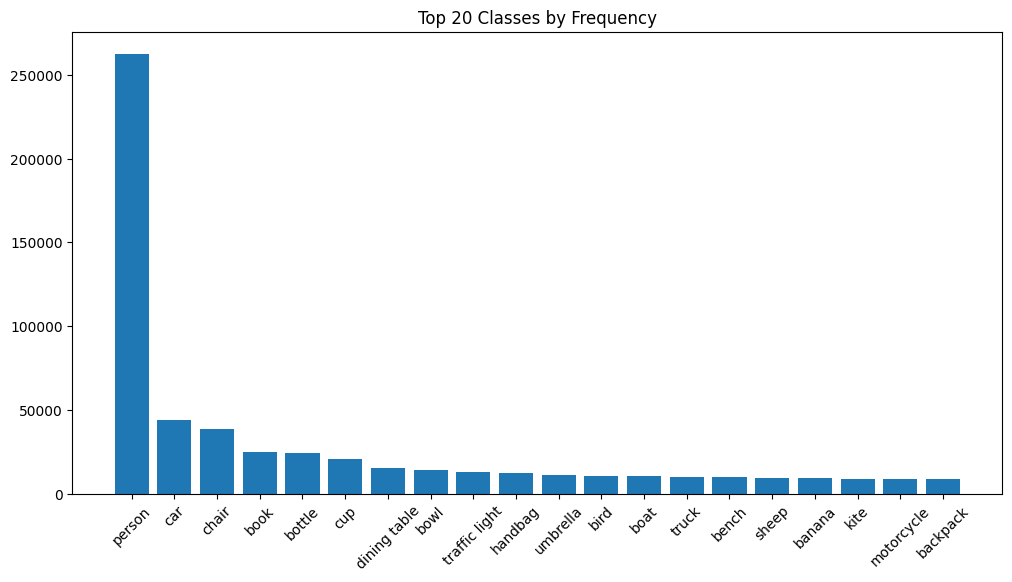

In [9]:
cat_counter = Counter()

for ann in annotations:
    cat_counter[ann['category_id']] += 1

# convert sang tên
cat_names = [cat_id_to_name[cid] for cid in cat_counter.keys()]
cat_values = list(cat_counter.values())

# sort
sorted_pairs = sorted(zip(cat_names, cat_values), key=lambda x: x[1], reverse=True)

names = [x[0] for x in sorted_pairs]
values = [x[1] for x in sorted_pairs]

plt.figure(figsize=(12,6))
plt.bar(names[:20], values[:20])  # top 20 class
plt.xticks(rotation=45)
plt.title("Top 20 Classes by Frequency")
plt.show()

### **6. Resolution ảnh**

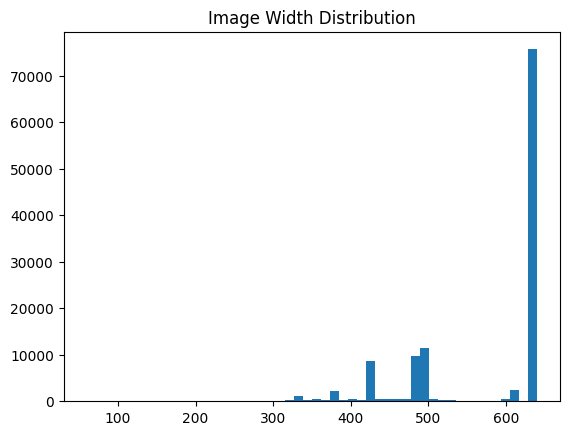

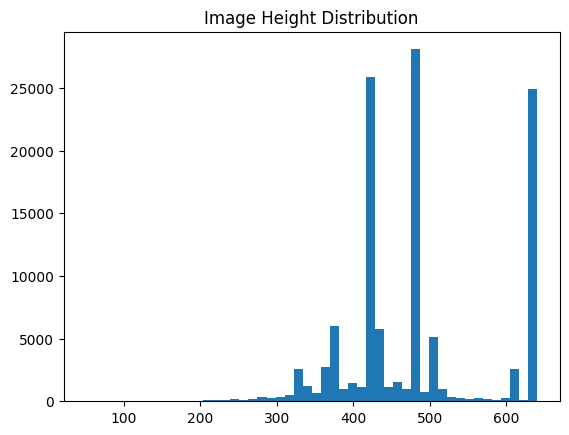

In [10]:
widths_img = [img['width'] for img in images]
heights_img = [img['height'] for img in images]

plt.figure()
plt.hist(widths_img, bins=50)
plt.title("Image Width Distribution")
plt.show()

plt.figure()
plt.hist(heights_img, bins=50)
plt.title("Image Height Distribution")
plt.show()

### **7. Mẫu**

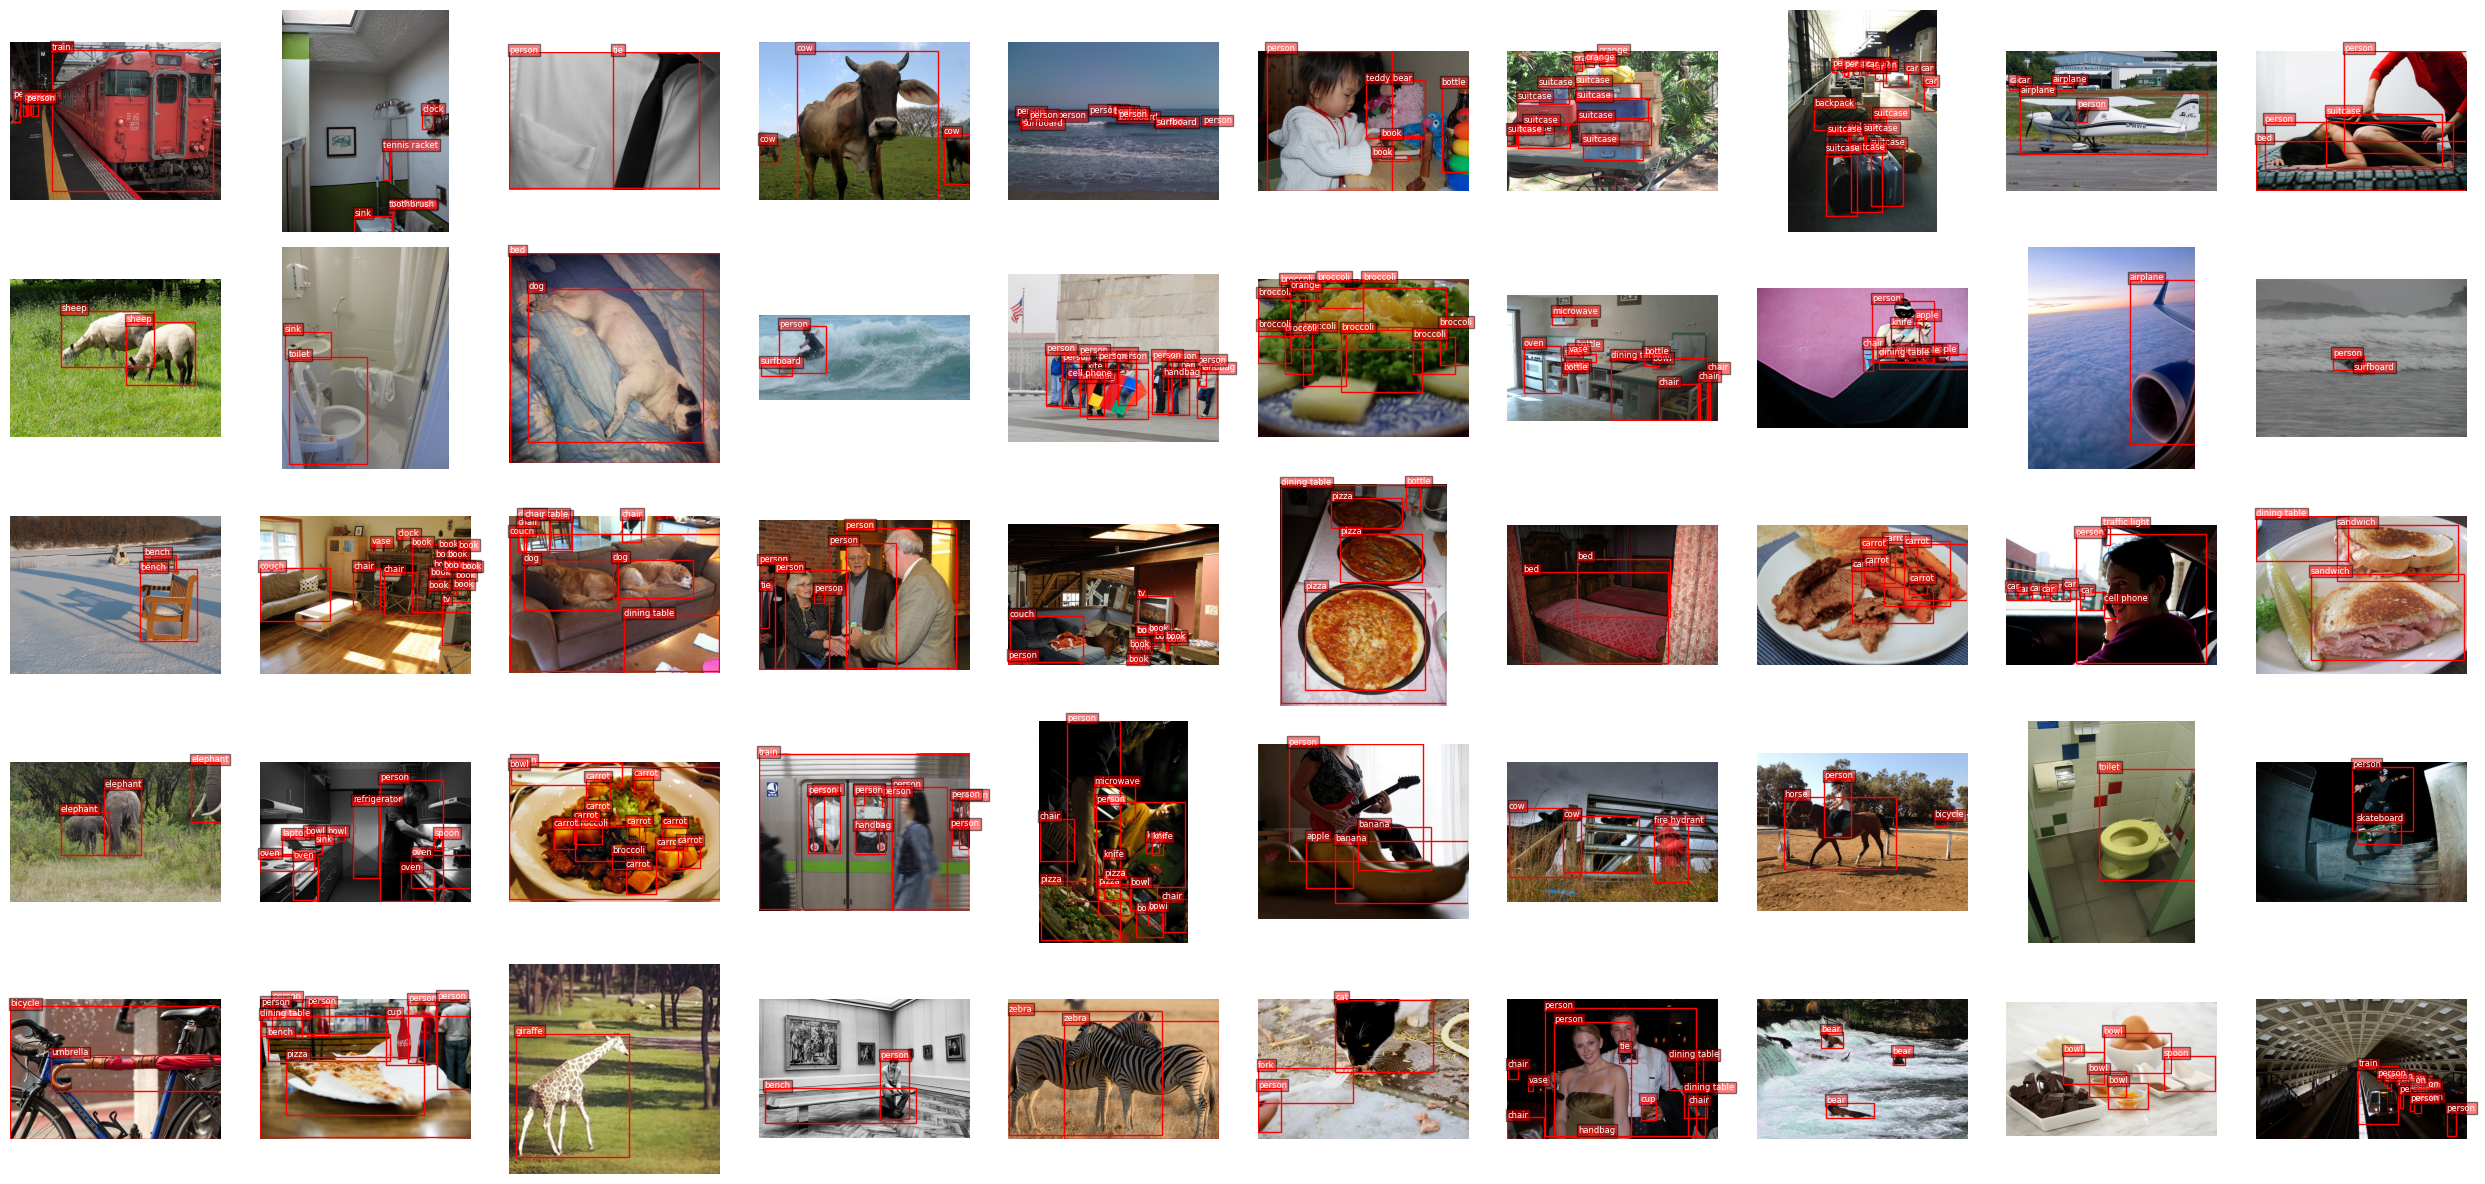

In [11]:
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# =========================
# BUILD IMAGE -> ANNOTATION MAP
# =========================
img_id_to_anns = {}

for ann in annotations:
    img_id = ann['image_id']
    if img_id not in img_id_to_anns:
        img_id_to_anns[img_id] = []
    img_id_to_anns[img_id].append(ann)

# =========================
# SAMPLE 50 IMAGES
# =========================
sample_images = random.sample(images, 50)

# =========================
# PLOT 5x10
# =========================
fig, axes = plt.subplots(5, 10, figsize=(25, 12))
axes = axes.flatten()

for idx, img_info in enumerate(sample_images):
    ax = axes[idx]

    img_path = os.path.join(IMG_DIR, img_info['file_name'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.axis('off')

    img_id = img_info['id']
    anns = img_id_to_anns.get(img_id, [])

    for ann in anns:
        x, y, w, h = ann['bbox']
        cat_id = ann['category_id']
        label = cat_id_to_name[cat_id]

        # vẽ bbox
        rect = patches.Rectangle(
            (x, y), w, h,
            linewidth=1,
            edgecolor='red',
            facecolor='none'
        )
        ax.add_patch(rect)

        # vẽ label
        ax.text(
            x, y,
            label,
            color='white',
            fontsize=6,
            bbox=dict(facecolor='red', alpha=0.5, pad=1)
        )

plt.tight_layout()
plt.show()